In [1]:

import numpy as np 
import pandas as pd 
import os
import cv2

## Labels

In [2]:
labels = os.listdir(r"dataset\train")

In [3]:
labels

['Closed', 'no_yawn', 'Open', 'yawn']

## Visualize A random image

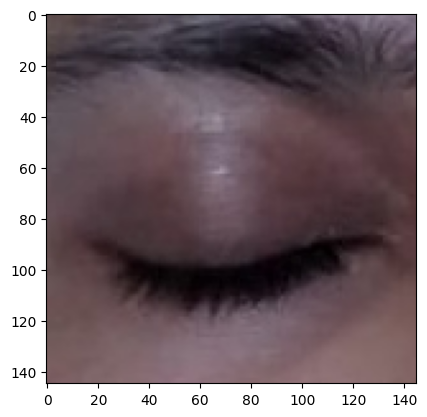

In [4]:
import matplotlib.pyplot as plt
plt.imshow(plt.imread(r"dataset\train\Closed\_0.jpg"))

## Image array

In [5]:
a = plt.imread(r"dataset\train\yawn\10.jpg")

## Image shape

In [6]:
a.shape

(480, 640, 3)

## Visualize yawn image(Background is unnecessary. We need only face image array) 


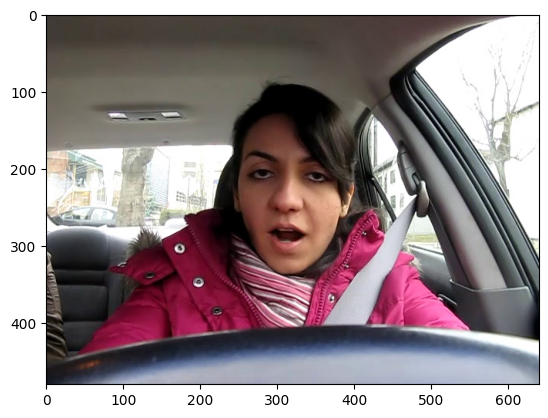

In [7]:
plt.imshow(plt.imread(r"dataset\train\yawn\10.jpg"))

## Take only face(For yawn and not_yawn)

In [8]:
def face_for_yawn(direc=r"dataset\train", face_cas_path=r"assets\haarcascade_frontalface_default.xml"):
    yaw_no = []
    IMG_SIZE = 145
    categories = ["yawn", "no_yawn"]
    for category in categories:
        path_link = os.path.join(direc, category)
        class_num1 = categories.index(category)
        print(class_num1)
        for image in os.listdir(path_link):
            image_array = cv2.imread(os.path.join(path_link, image), cv2.IMREAD_COLOR)
            face_cascade = cv2.CascadeClassifier(face_cas_path)
            faces = face_cascade.detectMultiScale(image_array, 1.3, 5)
            for (x, y, w, h) in faces:
                img = cv2.rectangle(image_array, (x, y), (x+w, y+h), (0, 255, 0), 2)
                roi_color = img[y:y+h, x:x+w]
                resized_array = cv2.resize(roi_color, (IMG_SIZE, IMG_SIZE))
                yaw_no.append([resized_array, class_num1])
    return yaw_no


yawn_no_yawn = face_for_yawn()

0
1


## For Closed and Open eye

In [9]:
def get_data(dir_path=r"dataset\train", face_cas=r"assets\haarcascade_frontalface_default.xml", eye_cas=r"assets\haarcascade.xml"):
    labels = ['Closed', 'Open']
    IMG_SIZE = 145
    data = []
    for label in labels:
        path = os.path.join(dir_path, label)
        class_num = labels.index(label)
        class_num +=2
        print(class_num)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                data.append([resized_array, class_num])
            except Exception as e:
                print(e)
    return data

In [10]:
data_train = get_data()

2
3


## Extend data and Convert array

In [14]:
def append_data():
#     total_data = []
    yaw_no = face_for_yawn()
    data = get_data()
    yaw_no.extend(data)
    return np.array(yaw_no, dtype=object)

## New variable to store

In [15]:
new_data = append_data()

0
1
2
3


## Separate label and features

In [16]:
X = []
y = []
for feature, label in new_data:
    X.append(feature)
    y.append(label)

## Reshape the Array

In [17]:
X = np.array(X)
X = X.reshape(-1, 145, 145, 3)

## LabelBinarizer

In [20]:
from sklearn.preprocessing import LabelBinarizer
label_bin = LabelBinarizer()
y = label_bin.fit_transform(y)

## Label array

In [21]:
y = np.array(y)

## Train Test split

In [22]:
from sklearn.model_selection import train_test_split
seed = 42
test_size = 0.30
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=test_size)

## Length of X_test

In [23]:
len(X_test)

578

## Import some dependencies

In [24]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

## Data Augmentation

In [25]:
train_generator = ImageDataGenerator(rescale=1/255, zoom_range=0.2, horizontal_flip=True, rotation_range=30)
test_generator = ImageDataGenerator(rescale=1/255)


#train_generator = tf.data.Dataset.from_tensor_slices((X_train, y_train))
#test_generator = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_generator = train_generator.flow(np.array(X_train), y_train, shuffle=False)
test_generator = test_generator.flow(np.array(X_test), y_test, shuffle=False)

# Model

In [26]:
model = Sequential()

model.add(Conv2D(256, (3, 3), activation="relu", input_shape=(145,145,3)))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Flatten())
model.add(Dropout(0.5))

model.add(Dense(64, activation="relu"))
model.add(Dense(4, activation="softmax"))

model.compile(loss="categorical_crossentropy", metrics=["accuracy"], optimizer="adam")

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 143, 143, 256)     7168      
                                                                 
 max_pooling2d (MaxPooling2  (None, 71, 71, 256)       0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 69, 69, 128)       295040    
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 34, 34, 128)       0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 64)        73792     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 16, 64)        0

In [27]:
history = model.fit(train_generator, epochs=50, validation_data=test_generator, shuffle=True, validation_steps=len(test_generator))

Epoch 1/50
43/43 [==============================] - 62s 1s/step - loss: 1.2733 - accuracy: 0.4232 - val_loss: 1.0654 - val_accuracy: 0.5536
Epoch 2/50
43/43 [==============================] - 60s 1s/step - loss: 0.6761 - accuracy: 0.7424 - val_loss: 0.4461 - val_accuracy: 0.8114
Epoch 3/50
43/43 [==============================] - 56s 1s/step - loss: 0.4423 - accuracy: 0.8122 - val_loss: 0.3062 - val_accuracy: 0.8720
Epoch 4/50
43/43 [==============================] - 56s 1s/step - loss: 0.3932 - accuracy: 0.8241 - val_loss: 0.3056 - val_accuracy: 0.8806
Epoch 5/50
43/43 [==============================] - 56s 1s/step - loss: 0.3284 - accuracy: 0.8619 - val_loss: 0.2381 - val_accuracy: 0.9066
Epoch 6/50
43/43 [==============================] - 57s 1s/step - loss: 0.3131 - accuracy: 0.8753 - val_loss: 0.3764 - val_accuracy: 0.8218
Epoch 7/50
43/43 [==============================] - 56s 1s/step - loss: 0.3043 - accuracy: 0.8760 - val_loss: 0.3072 - val_accuracy: 0.8962
Epoch 8/50
43/43 [==

## History

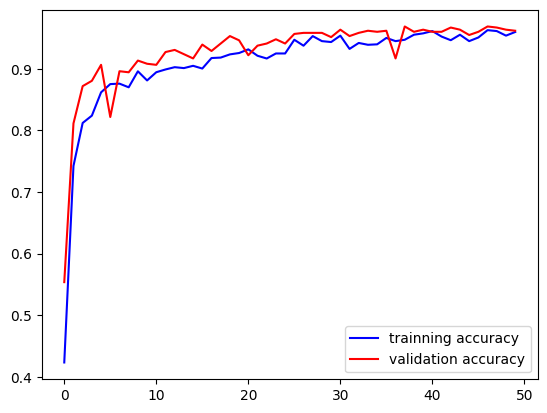

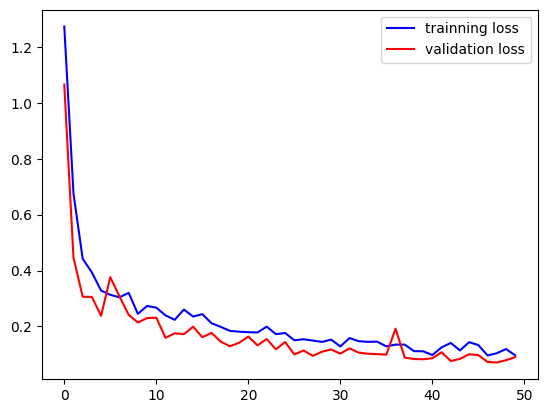

In [28]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(accuracy))

plt.plot(epochs, accuracy, "b", label="trainning accuracy")
plt.plot(epochs, val_accuracy, "r", label="validation accuracy")
plt.legend()
plt.show()

plt.plot(epochs, loss, "b", label="trainning loss")
plt.plot(epochs, val_loss, "r", label="validation loss")
plt.legend()
plt.show()

## Save Model

In [29]:
model.save("drowiness_new7.h5")

d:\8th sem\v3-ddds\.venv\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [30]:
model.save("drowiness_new7.model")

INFO:tensorflow:Assets written to: drowiness_new7.model\assets


INFO:tensorflow:Assets written to: drowiness_new7.model\assets


# Prediction

In [31]:
prediction = np.argmax(model.predict(X_test), axis=-1)

19/19 [==============================] - 6s 321ms/step


In [32]:
prediction

array([3, 3, 2, 3, 1, 3, 3, 2, 1, 2, 3, 3, 3, 2, 2, 2, 3, 0, 0, 3, 3, 3,
       2, 1, 1, 2, 2, 2, 3, 2, 3, 2, 3, 2, 1, 3, 3, 2, 0, 3, 3, 3, 2, 3,
       2, 2, 3, 3, 3, 3, 3, 1, 2, 1, 3, 3, 2, 2, 2, 0, 3, 3, 0, 2, 2, 3,
       2, 3, 2, 3, 1, 3, 3, 3, 2, 0, 0, 3, 1, 3, 2, 0, 3, 2, 3, 2, 2, 1,
       3, 3, 2, 3, 3, 3, 1, 0, 3, 0, 3, 3, 3, 1, 3, 1, 2, 3, 2, 1, 2, 2,
       1, 1, 2, 0, 0, 3, 3, 3, 3, 2, 3, 3, 3, 1, 1, 2, 3, 3, 2, 0, 3, 3,
       1, 3, 1, 2, 3, 3, 2, 0, 2, 2, 2, 1, 3, 3, 3, 3, 2, 0, 3, 3, 3, 3,
       3, 1, 1, 0, 3, 1, 3, 2, 2, 3, 2, 3, 3, 2, 3, 0, 3, 1, 2, 0, 3, 3,
       3, 2, 0, 2, 3, 0, 2, 1, 3, 2, 3, 1, 2, 0, 1, 3, 2, 2, 3, 3, 3, 0,
       3, 2, 3, 0, 2, 0, 0, 1, 2, 3, 2, 0, 3, 1, 2, 2, 2, 2, 1, 3, 1, 0,
       1, 0, 2, 3, 3, 3, 3, 0, 0, 2, 0, 0, 3, 3, 1, 3, 3, 1, 3, 3, 0, 1,
       0, 0, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 2, 0, 2, 3, 2, 0, 3, 3, 2, 2,
       3, 2, 2, 0, 3, 3, 2, 2, 2, 3, 3, 3, 3, 3, 0, 1, 0, 3, 3, 3, 3, 2,
       2, 0, 2, 2, 2, 3, 3, 0, 2, 2, 1, 3, 2, 3, 1,

# classification report

In [33]:
labels_new = ["yawn", "no_yawn", "Closed", "Open"]

In [34]:
from sklearn.metrics import classification_report
print(classification_report(np.argmax(y_test, axis=1), prediction, target_names=labels_new))

              precision    recall  f1-score   support

        yawn       0.79      0.89      0.84        63
     no_yawn       0.87      0.84      0.86        74
      Closed       1.00      0.90      0.95       215
        Open       0.93      1.00      0.96       226

    accuracy                           0.93       578
   macro avg       0.90      0.91      0.90       578
weighted avg       0.93      0.93      0.93       578



# predicting function

In [35]:
labels_new = ["yawn", "no_yawn", "Closed", "Open"]
IMG_SIZE = 145
def prepare(filepath, face_cas="../input/prediction-images/haarcascade_frontalface_default.xml"):
    img_array = cv2.imread(filepath, cv2.IMREAD_COLOR)
    img_array = img_array / 255
    resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
    return resized_array.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

model = tf.keras.models.load_model("./drowiness_new7.h5")

# Prediction 
## 0-yawn, 1-no_yawn, 2-Closed, 3-Open

In [36]:
# prepare("../input/drowsiness-dataset/train/no_yawn/1068.jpg")
prediction = model.predict([prepare(r"dataset\train\no_yawn\1067.jpg")])
np.argmax(prediction)

1/1 [==============================] - 0s 67ms/step


1

In [37]:
prediction = model.predict([prepare(r"dataset\train\Closed\_101.jpg")])
np.argmax(prediction)

1/1 [==============================] - 0s 30ms/step


2

In [38]:
prediction = model.predict([prepare(r"dataset\train\Closed\_104.jpg")])
np.argmax(prediction)

1/1 [==============================] - 0s 32ms/step


2

In [39]:
prediction = model.predict([prepare(r"dataset\train\yawn\12.jpg")])
np.argmax(prediction)


1/1 [==============================] - 0s 47ms/step


3

19/19 [==============================] - 6s 332ms/step


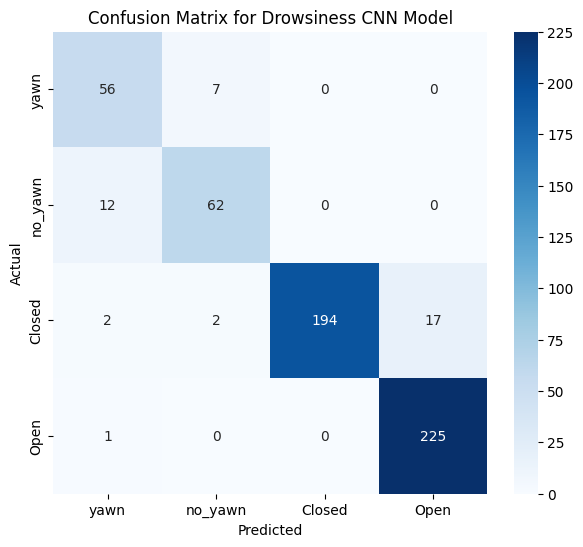

              precision    recall  f1-score   support

        yawn       0.79      0.89      0.84        63
     no_yawn       0.87      0.84      0.86        74
      Closed       1.00      0.90      0.95       215
        Open       0.93      1.00      0.96       226

    accuracy                           0.93       578
   macro avg       0.90      0.91      0.90       578
weighted avg       0.93      0.93      0.93       578



In [41]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model("drowiness_new7.h5")

# Predict on your test set
Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Define labels
labels_new = ["yawn", "no_yawn", "Closed", "Open"]

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_new, yticklabels=labels_new)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Drowsiness CNN Model')
plt.show()

# Print classification report
print(classification_report(y_true, y_pred, target_names=labels_new))